# **Exploratory Data Analysis of the MOEX Dataset**

This notebook presents an end-to-end exploratory and preparation workflow for MOEX equity data (2010-02-01 to 2026-02-01), using `security_descriptions`, `market_history` / `market_candles`, and `dividends` sources.

The pipeline includes:
- raw data loading and integrity checks;
- temporal coverage, liquidity, and delisting diagnostics;
- feature engineering for technical, financial, dividend, and static factors;
- forward target construction for 6M/42D/14D returns;
- final dataset validation;
- model-ready EDA with distribution, correlation, regime, and decile-profile analysis.

## **Raw Data Loading and Validation**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (14, 10)
plt.rcParams["font.size"] = 10

# Support both Kaggle runtime and local project execution.
if Path("/kaggle/input").exists():
    DATA_PATH = Path("/kaggle/input/datasets/rinapetuhova/moex-2010-2026/moex_dataset")
    PROCESSED_PATH = Path("/kaggle/working/moex_processed")
else:
    PROJECT_PATH = Path.cwd()
    DATA_PATH = PROJECT_PATH / "moex_dataset"
    PROCESSED_PATH = PROJECT_PATH / "moex_processed"

PROCESSED_PATH.mkdir(parents=True, exist_ok=True)

# Load all 1day data
day_path = DATA_PATH / "market_candles" / "1day"
files = list(day_path.glob("*.csv"))

dfs = []
for f in files:
    df = pd.read_csv(f)
    df["SECID"] = f.stem.replace("_1day", "")
    dfs.append(df)

market_history = pd.concat(dfs, ignore_index=True)
market_history["TRADEDATE"] = pd.to_datetime(market_history["begin"])
market_history = market_history.rename(
    columns={
        "open": "OPEN",
        "high": "HIGH",
        "low": "LOW",
        "close": "CLOSE",
        "value": "VALUE",
        "volume": "VOLUME",
    }
)
market_history = market_history[
    ["SECID", "TRADEDATE", "OPEN", "HIGH", "LOW", "CLOSE", "VOLUME", "VALUE"]
]

security_descriptions = pd.read_csv(DATA_PATH / "security_descriptions.csv")
dividends = pd.read_csv(DATA_PATH / "dividends.csv", sep=";")

print("=== MARKET HISTORY (1DAY) ===")
print("Shape:", market_history.shape)
print(
    "Date range:",
    market_history["TRADEDATE"].min(),
    "to",
    market_history["TRADEDATE"].max(),
)
print("Securities:", market_history["SECID"].nunique())

=== MARKET HISTORY (1DAY) ===
Shape: (737553, 8)
Date range: 2010-02-01 00:00:00 to 2026-02-01 00:00:00
Securities: 247


## **Data Quality Validation**

In [2]:
print("=== QUALITY CHECK: MARKET HISTORY ===")
missing = market_history.isnull().sum()
missing_pct = (missing / len(market_history) * 100).round(2)
print("Missing values in key columns:")
for col in ["OPEN", "HIGH", "LOW", "CLOSE", "VOLUME", "VALUE"]:
    print("  ", col, ":", missing_pct[col], "%")

print("\n=== DATE COVERAGE ===")
sec_dates = market_history.groupby("SECID")["TRADEDATE"].agg(["min", "max"])
sec_dates["days"] = (sec_dates["max"] - sec_dates["min"]).dt.days + 1
print("Average days per security:", int(sec_dates["days"].mean()))
print("Min days:", sec_dates["days"].min(), ", Max days:", sec_dates["days"].max())

=== QUALITY CHECK: MARKET HISTORY ===
Missing values in key columns:
   OPEN : 0.0 %
   HIGH : 0.0 %
   LOW : 0.0 %
   CLOSE : 0.0 %
   VOLUME : 0.0 %
   VALUE : 0.0 %

=== DATE COVERAGE ===
Average days per security: 4802
Min days: 780 , Max days: 5845


## **Temporal Range and Data Sufficiency Analysis**

=== HISTORY SUFFICIENCY ===
Securities with >3 years: 237
Securities with >2 years: 247
Securities with >1 year: 247


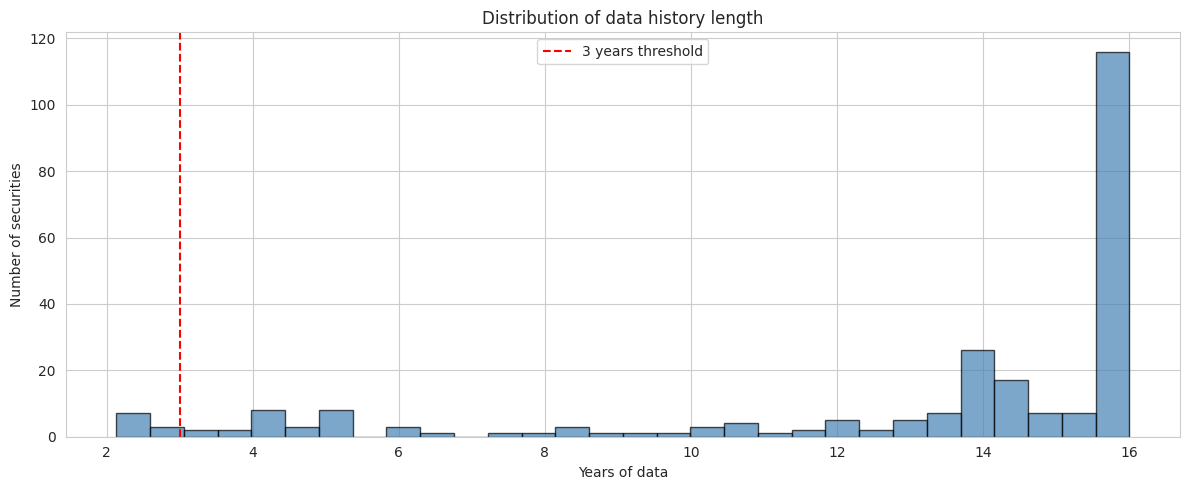

In [3]:
sec_dates = market_history.groupby("SECID")["TRADEDATE"].agg(["min", "max"])
sec_dates["years_of_data"] = (sec_dates["max"] - sec_dates["min"]).dt.days / 365.25

print("=== HISTORY SUFFICIENCY ===")
print("Securities with >3 years:", (sec_dates["years_of_data"] > 3).sum())
print("Securities with >2 years:", (sec_dates["years_of_data"] > 2).sum())
print("Securities with >1 year:", (sec_dates["years_of_data"] > 1).sum())

fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(
    sec_dates["years_of_data"], bins=30, edgecolor="black", alpha=0.7, color="steelblue"
)
ax.axvline(x=3, color="red", linestyle="--", label="3 years threshold")
ax.set_xlabel("Years of data")
ax.set_ylabel("Number of securities")
ax.set_title("Distribution of data history length")
ax.legend()
plt.tight_layout()
plt.show()

**Conclusion:** The dataset provides broad historical depth for most tickers, but coverage is uneven across securities; applying a minimum history threshold is necessary to ensure stable long-horizon feature computation.

## **Liquidity Analysis**

=== LIQUIDITY (2024) ===
Securities with avg_daily_value > 1M RUB: 215
Securities with avg_daily_value > 100K RUB: 242


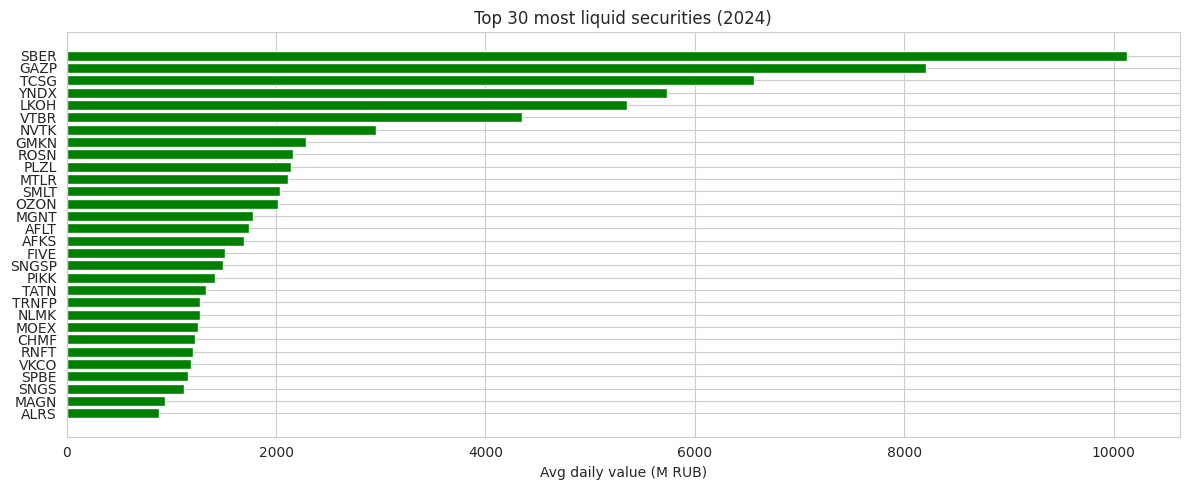

In [4]:
recent_data = market_history[market_history["TRADEDATE"] >= "2024-01-01"]

liquidity = recent_data.groupby("SECID")["VALUE"].mean().sort_values(ascending=False)

print("=== LIQUIDITY (2024) ===")
print("Securities with avg_daily_value > 1M RUB:", (liquidity > 1_000_000).sum())
print("Securities with avg_daily_value > 100K RUB:", (liquidity > 100_000).sum())

fig, ax = plt.subplots(figsize=(12, 5))
top_liq = liquidity.head(30)
ax.barh(top_liq.index, top_liq.values / 1e6, color="green")
ax.set_xlabel("Avg daily value (M RUB)")
ax.set_title("Top 30 most liquid securities (2024)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

**Conclusion:** Liquidity is highly concentrated, with many names showing structurally lower trading activity; liquidity-aware filtering and weighting are therefore important to maintain portfolio tradability.

## **Dividends and Delisting Analysis**

In [6]:
sec_dates = market_history.groupby("SECID")["TRADEDATE"].agg(["min", "max"])
sec_dates["is_active"] = sec_dates["max"] >= "2025-01-01"

print("=== DELISTING ===")
print("Active securities:", sec_dates["is_active"].sum())
print("Delisted:", (~sec_dates["is_active"]).sum())

print("\n=== DIVIDENDS ===")
dividends.columns = ["SECID", "isin", "registryclosedate", "value", "currencyid"]
dividends["registryclosedate"] = pd.to_datetime(dividends["registryclosedate"])
dividends["year"] = dividends["registryclosedate"].dt.year
div_by_year = dividends.groupby("year")["SECID"].nunique()
print("Securities with dividends:", dividends["SECID"].nunique())
print("Dividends by year:")
print(div_by_year)

=== DELISTING ===
Active securities: 231
Delisted: 16

=== DIVIDENDS ===
Securities with dividends: 163
Dividends by year:
year
2013     15
2014     35
2015     35
2016     36
2017     39
2018     76
2019    128
2020    114
2021    108
2022     95
2023    112
2024    121
2025     97
Name: SECID, dtype: int64


## **Data Cleaning and Preprocessing**

In [7]:
df = market_history.copy()

df = df.sort_values(["SECID", "TRADEDATE"]).reset_index(drop=True)

key_cols = ["TRADEDATE", "SECID", "OPEN", "HIGH", "LOW", "CLOSE"]
df = df.dropna(subset=key_cols)

print("After cleaning:", len(df), "rows")
print("Securities:", df["SECID"].nunique())

df.to_csv(PROCESSED_PATH / "market_history_corrected.csv", index=False)
print("\nSaved: market_history_corrected.csv")

After cleaning: 737553 rows
Securities: 247

Saved: market_history_corrected.csv


## **Technical Feature Engineering**

In [8]:
df = pd.read_csv(
    PROCESSED_PATH / "market_history_corrected.csv", parse_dates=["TRADEDATE"]
)


def calculate_momentum(df, periods):
    # Approximate month length as 21 trading days.
    for period in periods:
        col_name = "momentum_" + str(period) + "m"
        df[col_name] = df.groupby("SECID")["CLOSE"].transform(
            lambda x: x / x.shift(period * 21) - 1
        )
    return df


def calculate_volatility(df, periods):
    df = df.sort_values(["SECID", "TRADEDATE"])
    df["daily_return"] = df.groupby("SECID")["CLOSE"].pct_change()
    for period in periods:
        col_name = "volatility_" + str(period) + "m"
        trading_days = period * 21
        df[col_name] = df.groupby("SECID")["daily_return"].transform(
            lambda x: x.rolling(window=trading_days, min_periods=trading_days).std()
            * np.sqrt(252)
        )
    df = df.drop(columns=["daily_return"], errors="ignore")
    return df


def calculate_max_drawdown(df, periods):
    df = df.sort_values(["SECID", "TRADEDATE"])
    for period in periods:
        col_name = "max_drawdown_" + str(period) + "m"
        trading_days = period * 21

        def rolling_max_dd(group):
            prices = group["CLOSE"]
            # Peak-to-trough drawdown inside the rolling window.
            rolling_max = prices.rolling(
                window=trading_days, min_periods=trading_days
            ).max()
            drawdown = (prices - rolling_max) / rolling_max
            return drawdown.rolling(window=trading_days, min_periods=trading_days).min()

        df[col_name] = df.groupby("SECID", group_keys=False).apply(rolling_max_dd)
    return df


print("Calculating momentum...")
df = calculate_momentum(df, [6, 12, 24, 36])

print("Calculating volatility...")
df = calculate_volatility(df, [6, 12, 24, 36])

print("Calculating max_drawdown...")
df = calculate_max_drawdown(df, [6, 12, 24, 36])

print("Shape after technical features:", df.shape)

Calculating momentum...
Calculating volatility...
Calculating max_drawdown...
Shape after technical features: (737553, 20)


## **Financial Feature Engineering**

In [9]:
def calculate_avg_value(df, periods):
    for period in periods:
        col_name = "avg_value_" + str(period) + "m"
        trading_days = period * 21
        df[col_name] = df.groupby("SECID")["VALUE"].transform(
            lambda x: x.rolling(window=trading_days, min_periods=trading_days).mean()
        )
    return df


def calculate_relative_strength(df, index_ticker="MOEX"):
    # Broadcast MOEX close to all securities by date.
    index_data = df[df["SECID"] == index_ticker][["TRADEDATE", "CLOSE"]].copy()
    index_data.columns = ["TRADEDATE", "INDEX_CLOSE"]
    df = df.merge(index_data, on="TRADEDATE", how="left")
    df["relative_strength_12m"] = df["CLOSE"] / df["INDEX_CLOSE"]
    df = df.drop(columns=["INDEX_CLOSE"])
    return df


def calculate_excess_return(df, index_ticker="MOEX"):
    df = df.sort_values(["SECID", "TRADEDATE"])
    index_data = df[df["SECID"] == index_ticker][["TRADEDATE", "CLOSE"]].copy()
    index_data["INDEX_RETURN"] = index_data["CLOSE"].pct_change()
    index_data = index_data[["TRADEDATE", "INDEX_RETURN"]]
    df = df.merge(index_data, on="TRADEDATE", how="left")
    df["daily_return"] = df.groupby("SECID")["CLOSE"].pct_change()
    df["excess_daily_return"] = df["daily_return"] - df["INDEX_RETURN"]
    trading_days = 6 * 21
    df["excess_return_6m"] = df.groupby("SECID")["excess_daily_return"].transform(
        lambda x: (1 + x)
        .rolling(window=trading_days, min_periods=trading_days)
        .apply(lambda y: y.prod() - 1, raw=True)
    )
    df = df.drop(
        columns=["INDEX_RETURN", "daily_return", "excess_daily_return"], errors="ignore"
    )
    return df


def calculate_beta(df, index_ticker="MOEX"):
    df = df.sort_values(["SECID", "TRADEDATE"])
    index_data = df[df["SECID"] == index_ticker][["TRADEDATE", "CLOSE"]].copy()
    index_data["INDEX_RETURN"] = index_data["CLOSE"].pct_change()
    index_data = index_data[["TRADEDATE", "INDEX_RETURN"]]
    df = df.merge(index_data, on="TRADEDATE", how="left")
    df["daily_return"] = df.groupby("SECID")["CLOSE"].pct_change()

    def rolling_beta(group):
        # 12M rolling beta = cov(stock, index) / var(index).
        trading_days = 12 * 21
        cov = (
            group["daily_return"]
            .rolling(window=trading_days, min_periods=trading_days)
            .cov(group["INDEX_RETURN"])
        )
        var = (
            group["INDEX_RETURN"]
            .rolling(window=trading_days, min_periods=trading_days)
            .var()
        )
        return cov / var

    df["beta_12m"] = df.groupby("SECID", group_keys=False).apply(rolling_beta)
    df = df.drop(columns=["INDEX_RETURN", "daily_return"], errors="ignore")
    return df


print("Calculating avg_value...")
df = calculate_avg_value(df, [6, 12, 36])

print("Calculating relative_strength...")
df = calculate_relative_strength(df, "MOEX")

print("Calculating excess_return...")
df = calculate_excess_return(df, "MOEX")

print("Calculating beta...")
df = calculate_beta(df, "MOEX")

print("Shape after financial features:", df.shape)

Calculating avg_value...
Calculating relative_strength...
Calculating excess_return...
Calculating beta...
Shape after financial features: (737553, 26)


## **Dividend Feature Engineering**

In [10]:
dividends = pd.read_csv(DATA_PATH / "dividends.csv", sep=";")
dividends.columns = ["SECID", "isin", "registryclosedate", "value", "currencyid"]
dividends["registryclosedate"] = pd.to_datetime(dividends["registryclosedate"])
dividends = dividends[["SECID", "registryclosedate", "value"]].dropna()


def calculate_dividend_features(df, dividends):
    df = df.copy()

    # Aggregate dividend events to month level for rolling lookbacks.
    div_events = dividends.copy()
    div_events["year_month"] = div_events["registryclosedate"].dt.to_period("M")
    div_monthly = (
        div_events.groupby(["SECID", "year_month"])["value"].sum().reset_index()
    )

    df["year_month"] = df["TRADEDATE"].dt.to_period("M")

    results = []
    for sec in df["SECID"].unique():
        sec_df = df[df["SECID"] == sec].copy()
        sec_div = div_monthly[div_monthly["SECID"] == sec].copy()

        if sec_div.empty:
            for idx, row in sec_df.iterrows():
                results.append(
                    {
                        "SECID": sec,
                        "TRADEDATE": row["TRADEDATE"],
                        "dividend_yield_12m": np.nan,
                        "dividend_yield_3y_avg": np.nan,
                        "dividend_consistency_3y": 0,
                    }
                )
        else:
            # Compute trailing dividend features for each security-date observation.
            for idx, row in sec_df.iterrows():
                current_ym = row["year_month"]
                price = row["CLOSE"]

                if pd.isna(price) or price <= 0:
                    continue

                start_ym_12m = (
                    current_ym.to_timestamp() - pd.DateOffset(months=12)
                ).to_period("M")
                start_ym_3y = (
                    current_ym.to_timestamp() - pd.DateOffset(years=3)
                ).to_period("M")

                div_12m = sec_div[
                    (sec_div["year_month"] > start_ym_12m)
                    & (sec_div["year_month"] <= current_ym)
                ]["value"].sum()

                div_3y = sec_div[
                    (sec_div["year_month"] > start_ym_3y)
                    & (sec_div["year_month"] <= current_ym)
                ]["value"].sum()
                years_with_div = sec_div[
                    (sec_div["year_month"] > start_ym_3y)
                    & (sec_div["year_month"] <= current_ym)
                ]["year_month"].dt.year.nunique()

                results.append(
                    {
                        "SECID": sec,
                        "TRADEDATE": row["TRADEDATE"],
                        "dividend_yield_12m": div_12m / price if price > 0 else np.nan,
                        "dividend_yield_3y_avg": (
                            div_3y / price / 3 if price > 0 else np.nan
                        ),
                        "dividend_consistency_3y": min(years_with_div, 3) / 3,
                    }
                )

    div_features = pd.DataFrame(results)
    df = df.drop(columns=["year_month"], errors="ignore")
    df = df.merge(div_features, on=["SECID", "TRADEDATE"], how="left")

    return df


print("Calculating dividend features...")
df = calculate_dividend_features(df, dividends)

print("Shape after dividend features:", df.shape)

Calculating dividend features...
Shape after dividend features: (737555, 29)


## **Static Feature Engineering**

In [11]:
security_descriptions = pd.read_csv(DATA_PATH / "security_descriptions.csv")
issuesize = security_descriptions[["SECID", "ISSUESIZE"]].copy()
issuesize = issuesize.dropna(subset=["ISSUESIZE"])
issuesize["ISSUESIZE"] = np.log(issuesize["ISSUESIZE"])
issuesize.columns = ["SECID", "log_issuesize"]

df = df.merge(issuesize, on="SECID", how="left")

df.to_csv(PROCESSED_PATH / "features_all.csv", index=False)
print("Saved: features_all.csv", df.shape)

Saved: features_all.csv (737555, 30)


## **Target Engineering and Final Cleaning**

In [12]:
features_df = pd.read_csv(
    PROCESSED_PATH / "features_all.csv", parse_dates=["TRADEDATE"]
)

print("Cleaning extreme values...")
feature_cols = [
    "momentum_6m",
    "momentum_12m",
    "momentum_24m",
    "momentum_36m",
    "volatility_6m",
    "volatility_12m",
    "volatility_24m",
    "volatility_36m",
    "max_drawdown_6m",
    "max_drawdown_12m",
    "max_drawdown_24m",
    "max_drawdown_36m",
    "avg_value_6m",
    "avg_value_12m",
    "avg_value_36m",
    "dividend_yield_12m",
    "dividend_yield_3y_avg",
    "dividend_consistency_3y",
    "relative_strength_12m",
    "excess_return_6m",
    "beta_12m",
    "log_issuesize",
]

for col in feature_cols:
    # Keep static size feature intact; clip only rolling/ratio features.
    if col == "log_issuesize":
        continue
    q_low = features_df[col].quantile(0.001)
    q_high = features_df[col].quantile(0.999)
    features_df.loc[(features_df[col] < q_low) | (features_df[col] > q_high), col] = (
        np.nan
    )

features_df["beta_12m"] = features_df["beta_12m"].clip(-5, 5)

print("Calculating targets (182-day, 42-day, 14-day forward returns with dividends)...")
features_df = features_df.sort_values(["SECID", "TRADEDATE"])

# Load dividends
dividends = pd.read_csv(DATA_PATH / "dividends.csv", sep=";")
dividends.columns = ["SECID", "isin", "registryclosedate", "value", "currencyid"]
dividends["registryclosedate"] = pd.to_datetime(dividends["registryclosedate"])
dividends = dividends[["SECID", "registryclosedate", "value"]].dropna()

# Function to calculate total return (price + dividends)


def calculate_total_return(df, dividends, days):
    # Total forward return includes both price move and paid dividends.
    results = []

    for sec in df["SECID"].unique():
        sec_df = df[df["SECID"] == sec].copy()
        sec_div = dividends[dividends["SECID"] == sec].copy()

        for idx, row in sec_df.iterrows():
            t_date = row["TRADEDATE"]
            price_t = row["CLOSE"]

            if pd.isna(price_t) or price_t <= 0:
                continue

            # Future price at t + days
            future_date_mask = sec_df["TRADEDATE"] > t_date
            future_prices = sec_df[future_date_mask].sort_values("TRADEDATE")

            if len(future_prices) == 0:
                continue

            # Use the closest available trading date to the requested horizon.
            target_date = t_date + pd.Timedelta(days=days)
            future_prices["diff"] = abs(future_prices["TRADEDATE"] - target_date)
            closest = future_prices.loc[future_prices["diff"].idxmin()]
            price_future = closest["CLOSE"]

            # Sum dividends between t and t+days
            if not sec_div.empty:
                div_mask = (sec_div["registryclosedate"] > t_date) & (
                    sec_div["registryclosedate"] <= closest["TRADEDATE"]
                )
                dividends_sum = sec_div.loc[div_mask, "value"].sum()
            else:
                dividends_sum = 0
            # Total return = (price_change + dividends) / price_t
            total_return = (price_future - price_t + dividends_sum) / price_t

            results.append(
                {
                    "SECID": sec,
                    "TRADEDATE": t_date,
                    f"target_return_{days}d": total_return,
                }
            )

    return pd.DataFrame(results)


# Calculate targets with dividends
print("Calculating target_return_182d with dividends...")
target_182 = calculate_total_return(features_df, dividends, 182)

print("Calculating target_return_42d with dividends...")
target_42 = calculate_total_return(features_df, dividends, 42)

print("Calculating target_return_14d with dividends...")
target_14 = calculate_total_return(features_df, dividends, 14)

# Merge targets
features_df = features_df.merge(target_182, on=["SECID", "TRADEDATE"], how="left")
features_df = features_df.merge(target_42, on=["SECID", "TRADEDATE"], how="left")
features_df = features_df.merge(target_14, on=["SECID", "TRADEDATE"], how="left")

# Clip extreme values
features_df.loc[features_df["target_return_182d"] > 10, "target_return_182d"] = np.nan
features_df.loc[features_df["target_return_182d"] < -0.99, "target_return_182d"] = (
    np.nan
)
features_df.loc[features_df["target_return_42d"] > 5, "target_return_42d"] = np.nan
features_df.loc[features_df["target_return_42d"] < -0.99, "target_return_42d"] = np.nan
features_df.loc[features_df["target_return_14d"] > 2, "target_return_14d"] = np.nan
features_df.loc[features_df["target_return_14d"] < -0.99, "target_return_14d"] = np.nan

min_history_days = 3 * 252
sec_dates = (
    features_df.groupby("SECID").agg({"TRADEDATE": ["min", "max"]}).reset_index()
)
sec_dates.columns = ["SECID", "first_date", "last_date"]
sec_dates["has_3y_history"] = (
    sec_dates["last_date"] - sec_dates["first_date"]
).dt.days >= min_history_days
valid_securities = sec_dates[sec_dates["has_3y_history"]]["SECID"].tolist()

features_df = features_df[features_df["SECID"].isin(valid_securities)]
target_cols = ["target_return_182d", "target_return_42d", "target_return_14d"]
features_df = features_df.dropna(subset=feature_cols + target_cols)

features_df["year_month"] = features_df["TRADEDATE"].dt.to_period("M")

target_cols = ["target_return_182d", "target_return_42d", "target_return_14d"]
final_df = features_df[
    ["SECID", "TRADEDATE", "year_month", "CLOSE"] + feature_cols + target_cols
].copy()

# ============================================
# Add CBR Key Rate
# ============================================
cbr_rates = pd.read_csv(
    "/kaggle/input/datasets/thescri/cbr-rates/cbr_rates.csv",
    parse_dates=["start_date", "end_date"],
)

cbr_rates = cbr_rates.sort_values("start_date").reset_index(drop=True)


def get_cbr_rate(trade_date, cbr_df):
    mask = (cbr_df["start_date"] <= trade_date) & (trade_date <= cbr_df["end_date"])
    matched = cbr_df.loc[mask, "rate"]
    if not matched.empty:
        return matched.iloc[0]
    elif trade_date < cbr_df["start_date"].min():
        return np.nan
    else:
        return cbr_df.loc[cbr_df["end_date"].idxmax(), "rate"]


final_df["cbr_key_rate"] = final_df["TRADEDATE"].apply(
    lambda d: get_cbr_rate(d, cbr_rates)
)
final_df.to_csv(PROCESSED_PATH / "final_dataset.csv", index=False)
print("\nSaved: final_dataset.csv", final_df.shape)
print("CBR rate added successfully")

Cleaning extreme values...
Calculating targets (182-day, 42-day, 14-day forward returns with dividends)...
Calculating target_return_182d with dividends...
Calculating target_return_42d with dividends...
Calculating target_return_14d with dividends...

Saved: final_dataset.csv (274534, 30)
CBR rate added successfully


## **Final Dataset Validation**

In [13]:
final_df = pd.read_csv(PROCESSED_PATH / "final_dataset.csv", parse_dates=["TRADEDATE"])

print("=== FINAL DATASET ===")
print("Rows:", final_df.shape[0])
print("Columns:", final_df.shape[1])
print("Securities:", final_df["SECID"].nunique())
print("Date range:", final_df["TRADEDATE"].min(), "to", final_df["TRADEDATE"].max())

required_features = [
    "momentum_6m",
    "momentum_12m",
    "momentum_24m",
    "momentum_36m",
    "volatility_6m",
    "volatility_12m",
    "volatility_24m",
    "volatility_36m",
    "max_drawdown_6m",
    "max_drawdown_12m",
    "max_drawdown_24m",
    "max_drawdown_36m",
    "avg_value_6m",
    "avg_value_12m",
    "avg_value_36m",
    "dividend_yield_12m",
    "dividend_yield_3y_avg",
    "dividend_consistency_3y",
    "relative_strength_12m",
    "excess_return_6m",
    "beta_12m",
    "log_issuesize",
    "cbr_key_rate",
    "target_return_182d",
    "target_return_42d",
    "target_return_14d",
]

print("\n=== FEATURES CHECK ===")
for i, feat in enumerate(required_features, 1):
    status = "OK" if feat in final_df.columns else "MISSING"
    print(i, ". ", feat, ": ", status, sep="")

=== FINAL DATASET ===
Rows: 274534
Columns: 30
Securities: 143
Date range: 2016-02-09 00:00:00 to 2026-01-31 00:00:00

=== FEATURES CHECK ===
1. momentum_6m: OK
2. momentum_12m: OK
3. momentum_24m: OK
4. momentum_36m: OK
5. volatility_6m: OK
6. volatility_12m: OK
7. volatility_24m: OK
8. volatility_36m: OK
9. max_drawdown_6m: OK
10. max_drawdown_12m: OK
11. max_drawdown_24m: OK
12. max_drawdown_36m: OK
13. avg_value_6m: OK
14. avg_value_12m: OK
15. avg_value_36m: OK
16. dividend_yield_12m: OK
17. dividend_yield_3y_avg: OK
18. dividend_consistency_3y: OK
19. relative_strength_12m: OK
20. excess_return_6m: OK
21. beta_12m: OK
22. log_issuesize: OK
23. cbr_key_rate: OK
24. target_return_182d: OK
25. target_return_42d: OK
26. target_return_14d: OK


## **Feature Distribution Diagnostics**

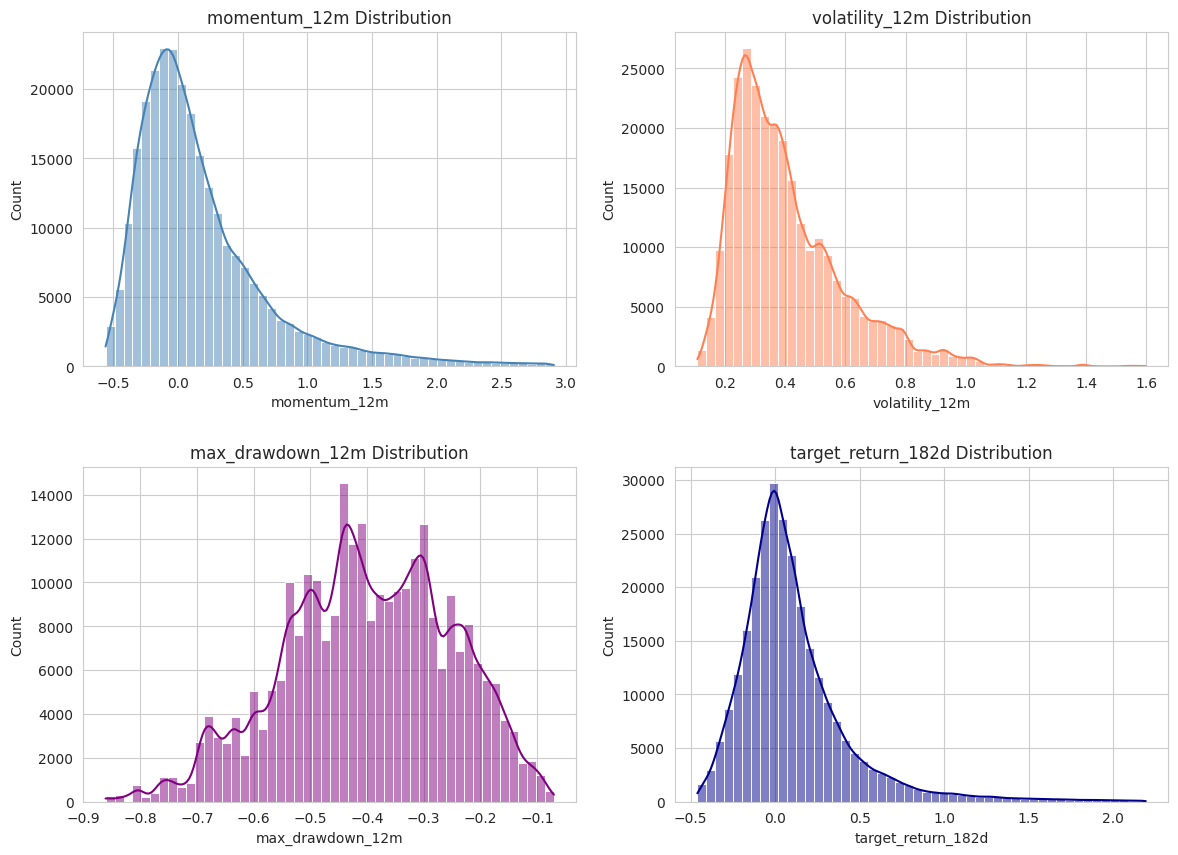

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

ax = axes[0, 0]
data = final_df["momentum_12m"].dropna()
data_clipped = data[(data > data.quantile(0.01)) & (data < data.quantile(0.99))]
sns.histplot(data=data_clipped, bins=50, kde=True, ax=ax, color="steelblue")
ax.set_title("momentum_12m Distribution")

ax = axes[0, 1]
sns.histplot(
    data=final_df["volatility_12m"].dropna(), bins=50, kde=True, ax=ax, color="coral"
)
ax.set_title("volatility_12m Distribution")

ax = axes[1, 0]
sns.histplot(
    data=final_df["max_drawdown_12m"].dropna(), bins=50, kde=True, ax=ax, color="purple"
)
ax.set_title("max_drawdown_12m Distribution")

ax = axes[1, 1]
target_col = (
    "target_return_182d"
    if "target_return_182d" in final_df.columns
    else "target_return"
)
target_series = final_df[target_col]
target_clipped = target_series[
    (target_series > target_series.quantile(0.01))
    & (target_series < target_series.quantile(0.99))
]
sns.histplot(data=target_clipped, bins=50, kde=True, ax=ax, color="darkblue")
ax.set_title(f"{target_col} Distribution")

fig.subplots_adjust(hspace=0.3)
plt.show()

**Conclusion:** The main feature distributions are economically plausible after clipping, but several variables remain non-Gaussian and heavy-tailed, which supports using robust non-linear models instead of relying on normality assumptions.

## **Feature Correlation Matrix**

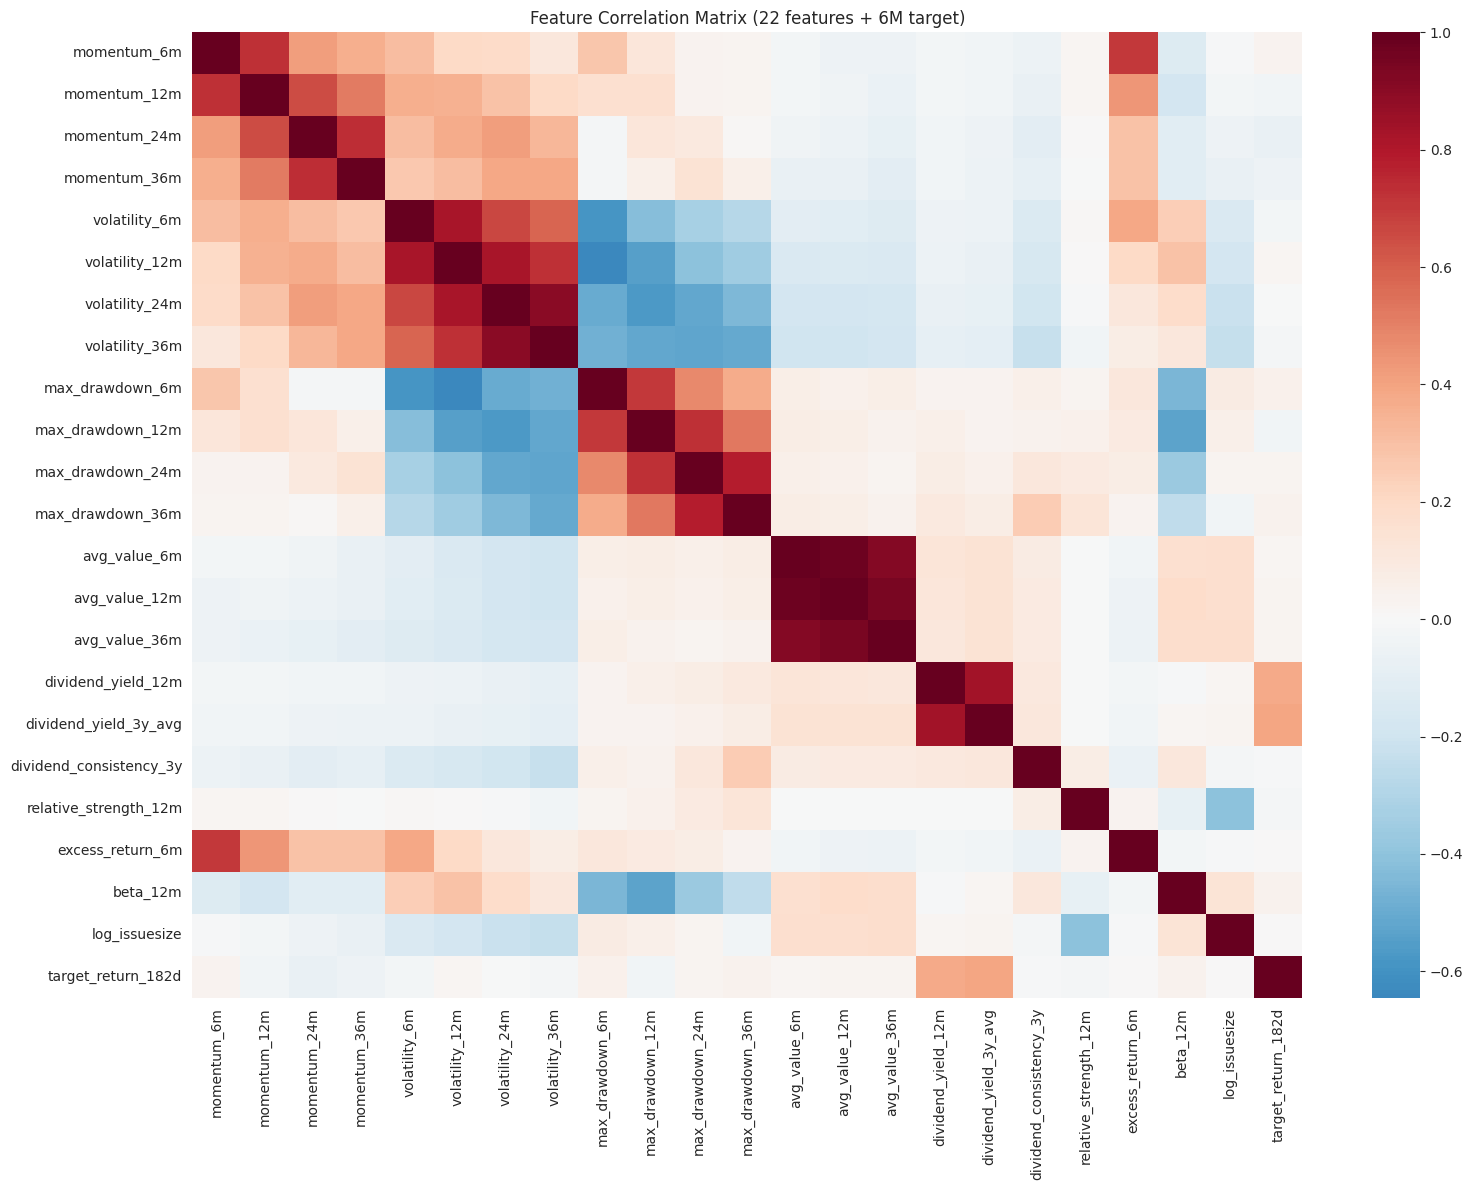

In [15]:
target_for_corr = (
    "target_return_182d"
    if "target_return_182d" in final_df.columns
    else "target_return"
)
features_for_corr = [
    "momentum_6m",
    "momentum_12m",
    "momentum_24m",
    "momentum_36m",
    "volatility_6m",
    "volatility_12m",
    "volatility_24m",
    "volatility_36m",
    "max_drawdown_6m",
    "max_drawdown_12m",
    "max_drawdown_24m",
    "max_drawdown_36m",
    "avg_value_6m",
    "avg_value_12m",
    "avg_value_36m",
    "dividend_yield_12m",
    "dividend_yield_3y_avg",
    "dividend_consistency_3y",
    "relative_strength_12m",
    "excess_return_6m",
    "beta_12m",
    "log_issuesize",
]
feature_cols_all = [
    c for c in features_for_corr + [target_for_corr] if c in final_df.columns
]
corr = final_df[feature_cols_all].corr()

fig, ax = plt.subplots(figsize=(16, 12))
sns.heatmap(corr, annot=False, cmap="RdBu_r", center=0, ax=ax)
ax.set_title("Feature Correlation Matrix (22 features + 6M target)")
plt.tight_layout()
plt.show()

**Conclusion:** The correlation structure shows expected clusters among same-family features across horizons, indicating some multicollinearity; this is acceptable for tree-based models, but feature importance should be interpreted with caution.

## **EDA**

In [16]:
from pathlib import Path

plot_df = final_df.copy()
plot_df["year"] = plot_df["TRADEDATE"].dt.year
plot_df["month"] = plot_df["TRADEDATE"].dt.to_period("M").astype(str)
target_col = (
    "target_return_182d" if "target_return_182d" in plot_df.columns else "target_return"
)
plots_dir = PROCESSED_PATH / "eda_plots_6m"
# Save chart snapshots for reporting/review outside the notebook.
Path(plots_dir).mkdir(parents=True, exist_ok=True)

features_22 = [
    "momentum_6m",
    "momentum_12m",
    "momentum_24m",
    "momentum_36m",
    "volatility_6m",
    "volatility_12m",
    "volatility_24m",
    "volatility_36m",
    "max_drawdown_6m",
    "max_drawdown_12m",
    "max_drawdown_24m",
    "max_drawdown_36m",
    "avg_value_6m",
    "avg_value_12m",
    "avg_value_36m",
    "dividend_yield_12m",
    "dividend_yield_3y_avg",
    "dividend_consistency_3y",
    "excess_return_6m",
    "beta_12m",
    "relative_strength_12m",
    "log_issuesize",
]

## **Target Return Distribution**

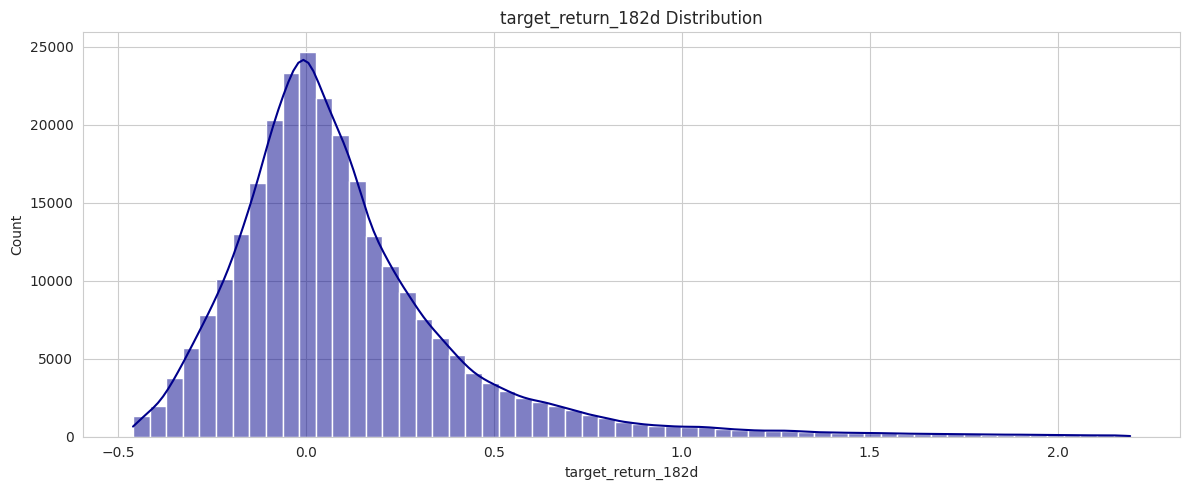

In [17]:
fig, ax = plt.subplots(figsize=(12, 5))
target = plot_df[target_col].dropna()
target_clipped = target[
    (target > target.quantile(0.01)) & (target < target.quantile(0.99))
]
sns.histplot(data=target_clipped, bins=60, kde=True, ax=ax, color="darkblue")
ax.set_title(f"{target_col} Distribution")
plt.tight_layout()
fig.savefig(plots_dir / "01_target_distribution.png", dpi=140)
plt.show()

**Conclusion:** The 6-month forward return distribution is wide and right-skewed: most observations are near zero, while a smaller set of strong positive outcomes creates a long upper tail.

## **Monthly Median Target Return**

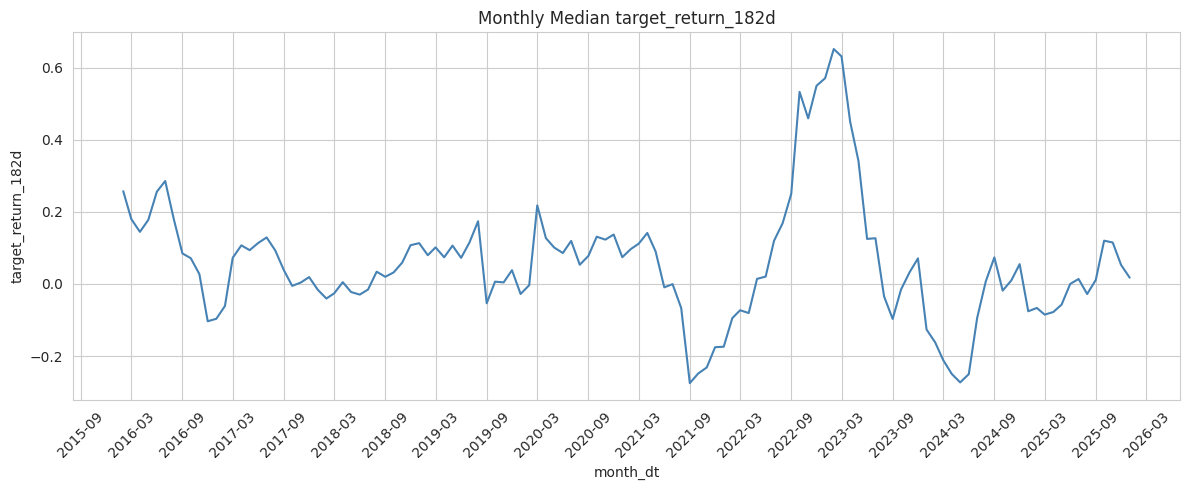

In [18]:
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(12, 5))
monthly_target = plot_df.groupby("month")[target_col].median().reset_index()
monthly_target["month_dt"] = pd.to_datetime(monthly_target["month"])
sns.lineplot(
    data=monthly_target,
    x="month_dt",
    y=target_col,
    ax=ax,
    color="steelblue",
    linewidth=1.5,
)
ax.set_title(f"Monthly Median {target_col}")
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
fig.savefig(plots_dir / "02_monthly_median_target.png", dpi=140)
plt.show()

**Conclusion:** Monthly median 6-month returns are regime-dependent and highly variable over time, so a time-aware split and regular model recalibration are important.

## **Share of Positive Returns by Month**

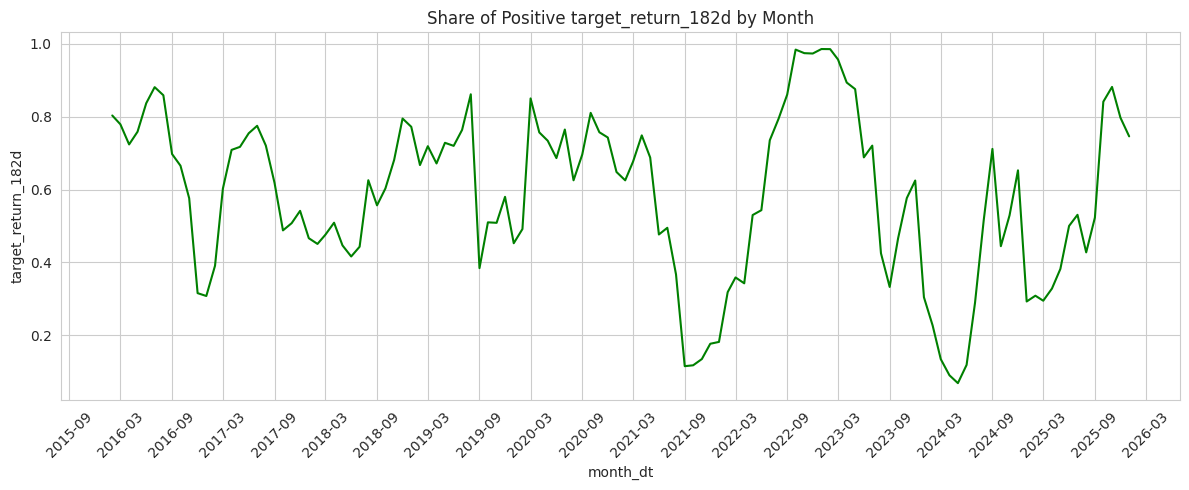

In [19]:
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(12, 5))
monthly_pos_share = (
    plot_df.groupby("month")[target_col].apply(lambda x: (x > 0).mean()).reset_index()
)
monthly_pos_share["month_dt"] = pd.to_datetime(monthly_pos_share["month"])
sns.lineplot(
    data=monthly_pos_share,
    x="month_dt",
    y=target_col,
    ax=ax,
    color="green",
    linewidth=1.5,
)
ax.set_title(f"Share of Positive {target_col} by Month")
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
fig.savefig(plots_dir / "03_positive_share_by_month.png", dpi=140)
plt.show()

**Conclusion:** The fraction of winners changes drastically across months, confirming strong market-state effects and supporting a selective process before portfolio construction.

## **Missing Share Heatmap**

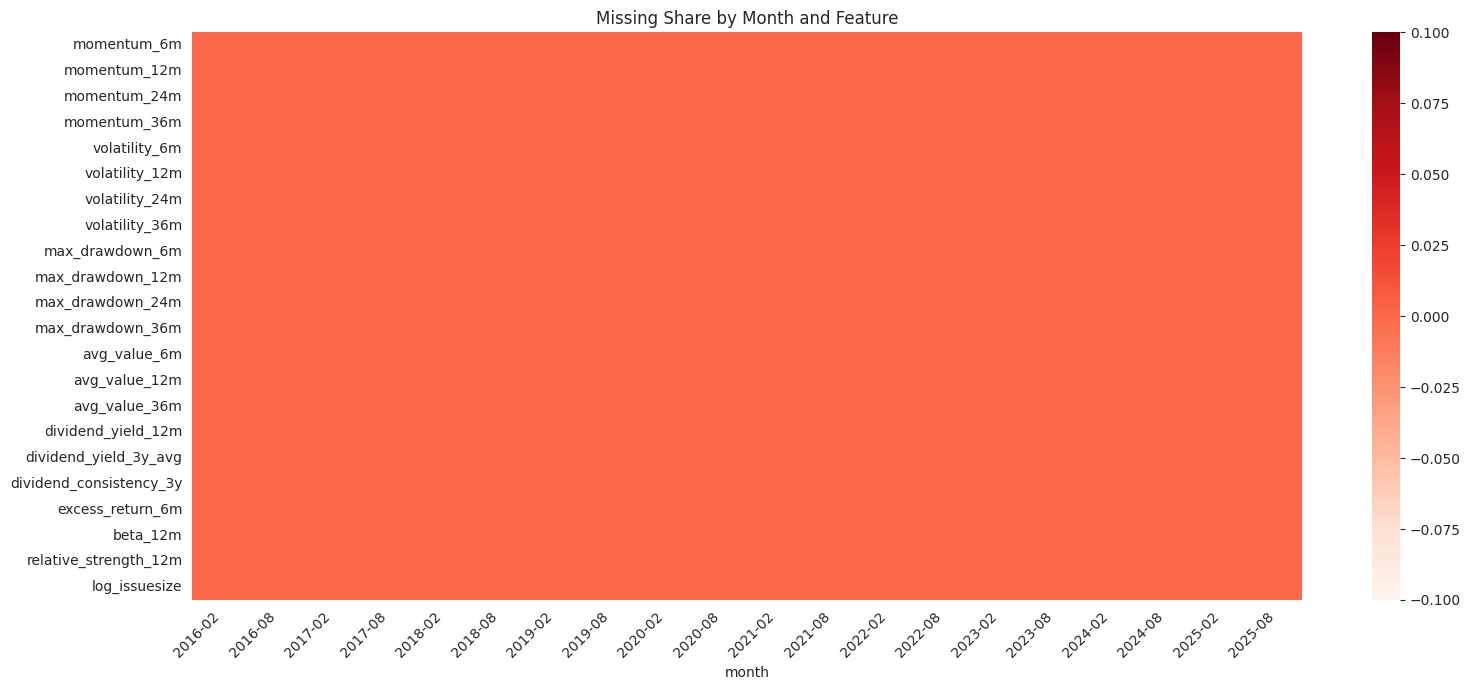

In [20]:
fig, ax = plt.subplots(figsize=(16, 7))
missing_by_month = plot_df.groupby("month")[features_22].apply(
    lambda x: x.isna().mean()
)
sns.heatmap(missing_by_month.T, cmap="Reds", cbar=True, ax=ax, xticklabels=6)
ax.set_title("Missing Share by Month and Feature")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
fig.savefig(plots_dir / "04_missing_heatmap.png", dpi=140)
plt.show()

**Conclusion:** Feature completeness is consistently high across the sample, so the modeling pipeline can operate without heavy imputation logic for these 22 features.

## **Spearman Correlation with Target**

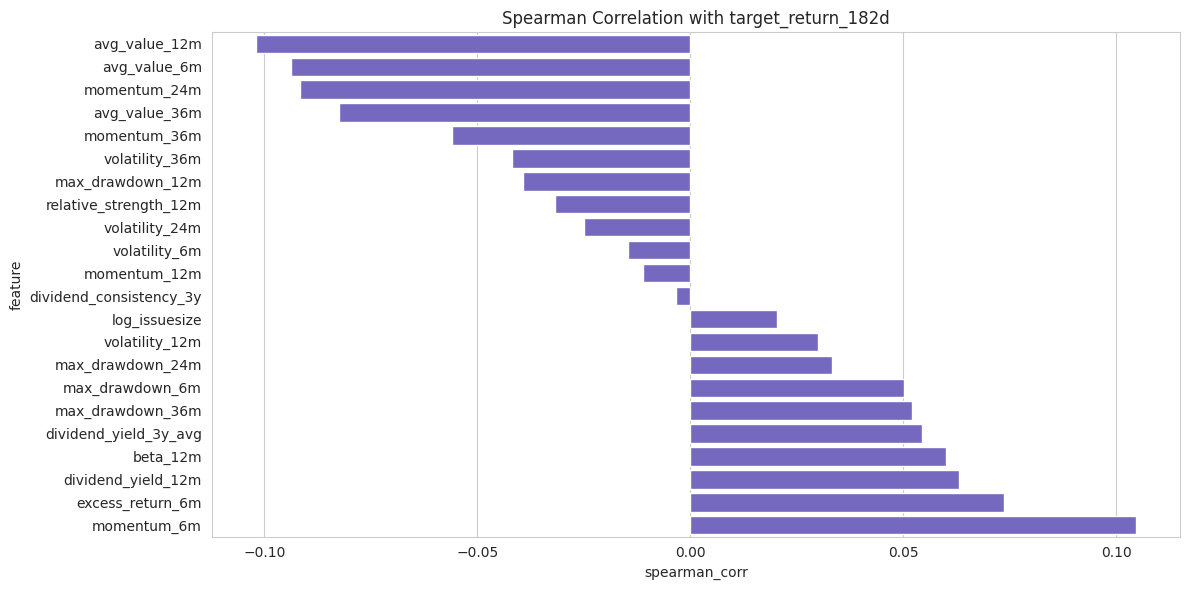

In [21]:
fig, ax = plt.subplots(figsize=(12, 6))
corr_target = (
    plot_df[features_22 + [target_col]]
    .corr(method="spearman")[target_col]
    .drop(target_col)
    .sort_values()
)
corr_df = corr_target.reset_index()
corr_df.columns = ["feature", "spearman_corr"]
sns.barplot(data=corr_df, x="spearman_corr", y="feature", ax=ax, color="slateblue")
ax.set_title(f"Spearman Correlation with {target_col}")
plt.tight_layout()
fig.savefig(plots_dir / "05_spearman_to_target.png", dpi=140)
plt.show()

**Conclusion:** Individual feature-to-target correlations are mostly modest, which is consistent with using a non-linear ensemble model to capture interaction effects rather than relying on one dominant predictor.

## **Momentum Decile Profile**

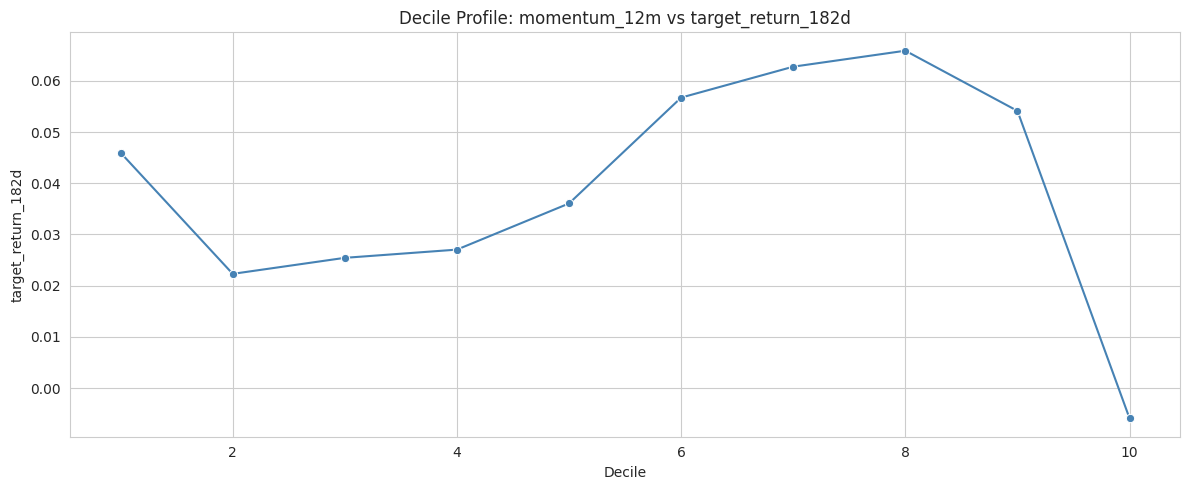

In [22]:
fig, ax = plt.subplots(figsize=(12, 5))
feature_name = "momentum_12m"
tmp = plot_df[[feature_name, target_col]].dropna().copy()
tmp["bin"] = pd.qcut(tmp[feature_name], q=10, duplicates="drop")
qplot = tmp.groupby("bin", observed=False)[target_col].median().reset_index()
qplot["decile"] = range(1, len(qplot) + 1)
sns.lineplot(data=qplot, x="decile", y=target_col, ax=ax, marker="o", color="steelblue")
ax.set_title(f"Decile Profile: {feature_name} vs {target_col}")
ax.set_xlabel("Decile")
plt.tight_layout()
fig.savefig(plots_dir / "06_decile_momentum_12m.png", dpi=140)
plt.show()

**Conclusion:** The relationship for 12M momentum is not a clean monotonic premium here; higher momentum deciles do not consistently deliver higher forward 6M returns, indicating dependence on market regime and interactions with other factors.

## **Volatility Decile Profile**

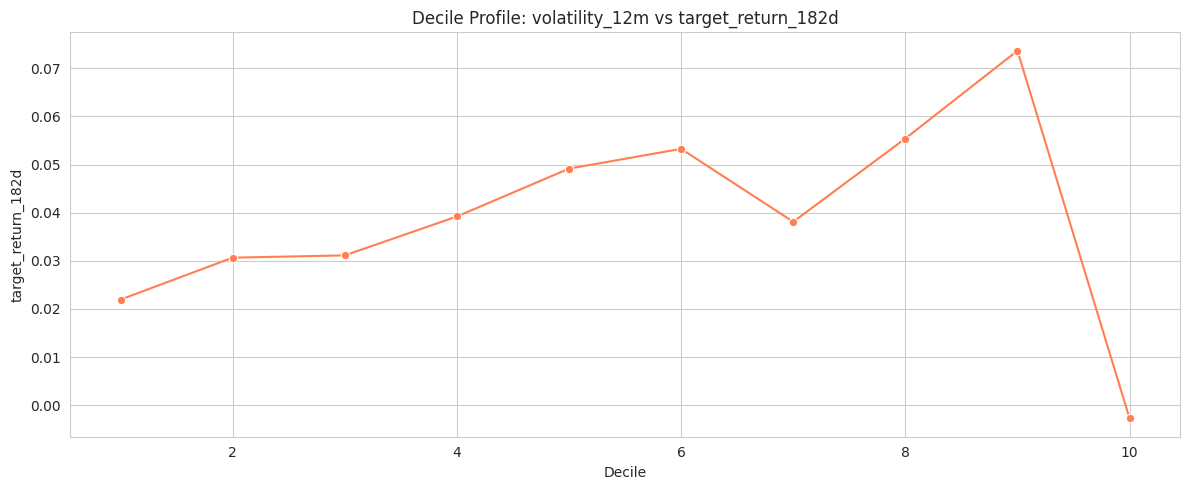

In [23]:
fig, ax = plt.subplots(figsize=(12, 5))
feature_name = "volatility_12m"
tmp = plot_df[[feature_name, target_col]].dropna().copy()
tmp["bin"] = pd.qcut(tmp[feature_name], q=10, duplicates="drop")
qplot = tmp.groupby("bin", observed=False)[target_col].median().reset_index()
qplot["decile"] = range(1, len(qplot) + 1)
sns.lineplot(data=qplot, x="decile", y=target_col, ax=ax, marker="o", color="coral")
ax.set_title(f"Decile Profile: {feature_name} vs {target_col}")
ax.set_xlabel("Decile")
plt.tight_layout()
fig.savefig(plots_dir / "07_decile_volatility_12m.png", dpi=140)
plt.show()

**Conclusion:** Higher volatility tends to correspond to slightly weaker median forward returns, but the effect size is small, so volatility is likely more useful in combination with other signals.

## **Beta Decile Profile**

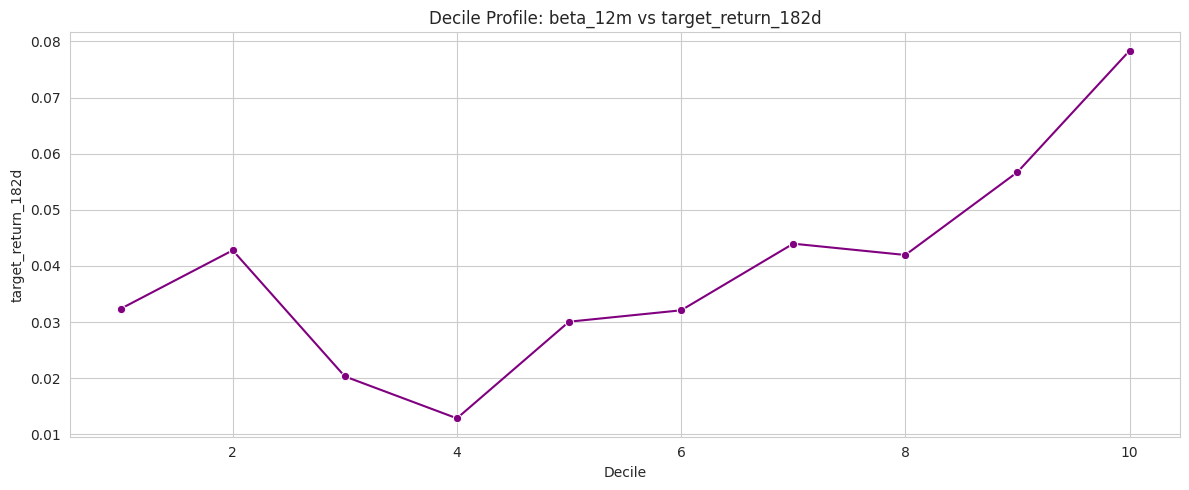

In [24]:
fig, ax = plt.subplots(figsize=(12, 5))
feature_name = "beta_12m"
tmp = plot_df[[feature_name, target_col]].dropna().copy()
tmp["bin"] = pd.qcut(tmp[feature_name], q=10, duplicates="drop")
qplot = tmp.groupby("bin", observed=False)[target_col].median().reset_index()
qplot["decile"] = range(1, len(qplot) + 1)
sns.lineplot(data=qplot, x="decile", y=target_col, ax=ax, marker="o", color="purple")
ax.set_title(f"Decile Profile: {feature_name} vs {target_col}")
ax.set_xlabel("Decile")
plt.tight_layout()
fig.savefig(plots_dir / "08_decile_beta_12m.png", dpi=140)
plt.show()

**Conclusion:** Higher-beta names show better median forward returns in this sample, suggesting market-sensitivity carries upside in favorable phases but should still be controlled at the portfolio-risk layer.

## **Securities Coverage by Month**

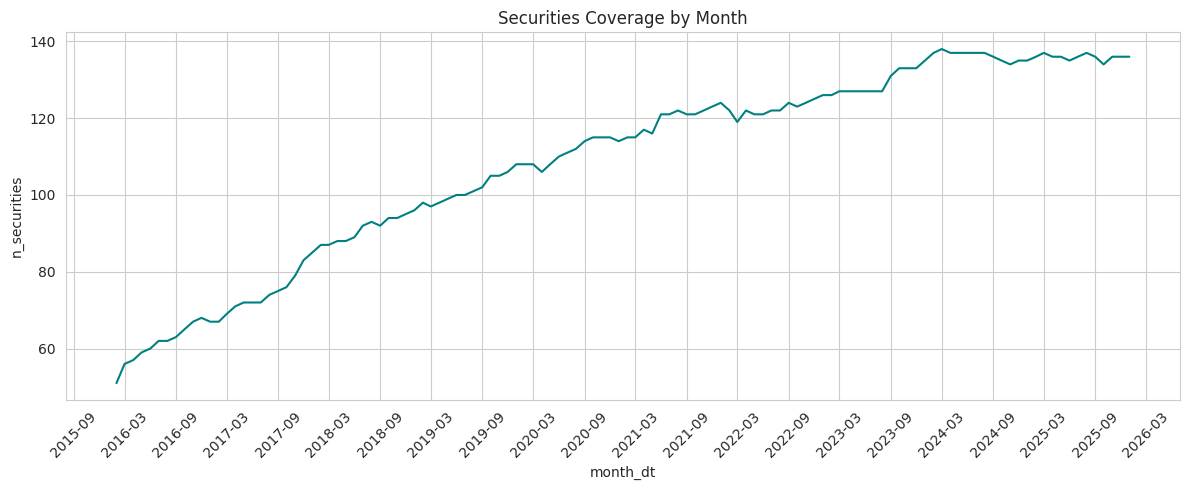

In [25]:
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(12, 5))
monthly_coverage = (
    plot_df.groupby("month")["SECID"].nunique().reset_index(name="n_securities")
)
monthly_coverage["month_dt"] = pd.to_datetime(monthly_coverage["month"])
sns.lineplot(
    data=monthly_coverage,
    x="month_dt",
    y="n_securities",
    ax=ax,
    color="teal",
    linewidth=1.5,
)
ax.set_title("Securities Coverage by Month")
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
fig.savefig(plots_dir / "09_monthly_coverage.png", dpi=140)
plt.show()

**Conclusion:** Cross-sectional coverage is broad and relatively stable, which supports robust monthly ranking, clustering, and top-selection steps.

## **Liquidity Decile Profile**

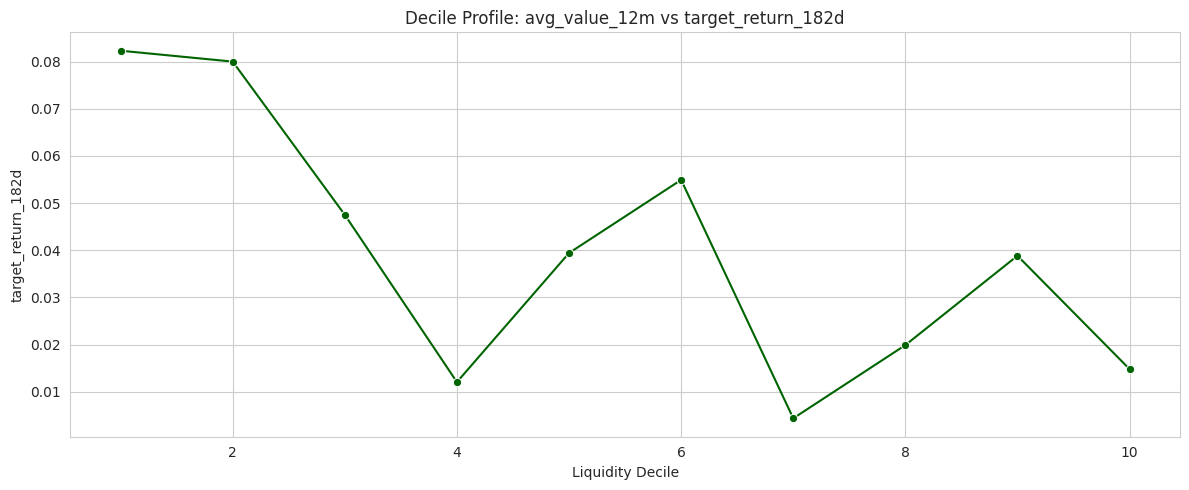

Charts saved to: /kaggle/working/moex_processed/eda_plots_6m


In [26]:
fig, ax = plt.subplots(figsize=(12, 5))
liq_feature = "avg_value_12m"
tmp = plot_df[[liq_feature, target_col]].dropna().copy()
tmp["liq_bin"] = pd.qcut(tmp[liq_feature], q=10, duplicates="drop")
liq_plot = tmp.groupby("liq_bin", observed=False)[target_col].median().reset_index()
liq_plot["decile"] = range(1, len(liq_plot) + 1)
sns.lineplot(
    data=liq_plot, x="decile", y=target_col, ax=ax, marker="o", color="darkgreen"
)
ax.set_title(f"Decile Profile: {liq_feature} vs {target_col}")
ax.set_xlabel("Liquidity Decile")
plt.tight_layout()
fig.savefig(plots_dir / "10_decile_avg_value_12m.png", dpi=140)
plt.show()

print(f"Charts saved to: {plots_dir}")

**Conclusion:** In this dataset, higher-liquidity deciles have lower median forward returns, indicating a small-size/liquidity premium that can complement alpha selection while capacity constraints are handled separately.